# Worksheet 1: Elementary programming
## 23MS121 
## Manish Behera

### Q1
Write a function is prime that checks whether a given integer (n) is prime. For this,
check whether any integer from 2 to [√n] divides n. If it does, then the function should return false
else it should return true.

In [86]:
import numpy as np
import math

def is_prime(n):
    """returns True if input n is prime, else returns False"""
    if n < 2: #catch all for 0 and 1
        return False
    for i in range(2,math.floor(np.sqrt(n)+1)): #looop to check
        if (n % i == 0):
            return False
    return True
print("The Number 6 is prime:",  is_prime(6))
            

The Number 6 is prime: False


### Q2. 
Write a function that generates all prime numbers between any two given integers.

In [106]:
def prime_gen(a , b):
    """Generates prime numbers betweeen the range [a,b]"""
    return [i for i in range(a,b+1) if is_prime(i)] #make and return da list 
print(prime_gen(1,10))

[2, 3, 5, 7]


### Q3.
Write a function f(x, N) that evaluates the series
exp(x) = 1 + x
1! + x2
2! + x3
3! + · · · =
∞X
n=0
xn
n!
upto N th term, for given x and N . Note: Please avoid calculating the factorial and express each
iterate in terms of the previous one.

In [71]:
def f(x,n):
    """retuns e^x for a given x calculated till n iterations via taylor expansion"""
    fac = 1
    val = 1
    if n == 0:
        return 1.0 #default val at n = 0 is 1 to avoid divide by 0 error
    else:
        for i in range(1,n+1): 
            val += (math.pow(x,i)/(fac*i))
            fac = fac*i    # no need to recalc we just multiply again to get new factorial
            #print(i, math.pow(x,i)/fac*i, val)
    return val

print(f(6,100))

403.4287934927351


### Q4. 
write a program that prints the calculated values of f(x,n) for x = 0.1, 0.2, . . . , 1.0 for
n = 4, 8, 12, 16, 20. Your program should print a table where rows correspond to changing x and
columns correspond to changing n. The table should be formatted to contain exactly 6 decimal
places for each number.

In [108]:
import pandas as pd
tab = []

x_vals = [round(i, 1) for i in np.arange(0.1, 1.1, 0.1)]  # round to get rid of floating point error :(
n_vals = [i for i in range(4, 24, 4)]

for x in x_vals:
    tab.append([f(x,n) for n in n_vals]) 
#print(tab)

#print dataframe using pandas
column_names = [f'n={n}' for n in n_vals]
row_names = [f'x={x}' for x in x_vals]

df = pd.DataFrame(tab, columns=column_names, index=row_names)
pd.set_option('display.precision', 6)
display(df)

,n=4,n=8,n=12,n=16,n=20
x=0.1,1.105171,1.105171,1.105171,1.105171,1.105171
x=0.2,1.221400,1.221403,1.221403,1.221403,1.221403
x=0.3,1.349838,1.349859,1.349859,1.349859,1.349859
x=0.4,1.491733,1.491825,1.491825,1.491825,1.491825
x=0.5,1.648438,1.648721,1.648721,1.648721,1.648721
x=0.6,1.821400,1.822119,1.822119,1.822119,1.822119
x=0.7,2.012171,2.013753,2.013753,2.013753,2.013753
x=0.8,2.222400,2.225541,2.225541,2.225541,2.225541
x=0.9,2.453837,2.459602,2.459603,2.459603,2.459603
x=1.0,2.708333,2.718279,2.718282,2.718282,2.718282


### Q5.  
Write a function that uses the continued fraction
4
π = 1 + 12
2 + 32
2 + 52
2 + 72
2 + . . .
to evaluate π upto n terms. Also write a function that uses Leibniz formula
π
4 = 1 − 1
3 + 1
5 − 1
7 + 1
9 − . . .
to evaluate π upto n terms.
Write a program that prints the output of both the functions for n = 1, 2, . . . , 10 (as a formatted
table with 8 decimal places for each number). Compare their convergence by plotting them in the
same plot versus n.

In [109]:
def continued_frac(n,i=0):
    """Aproxximation of pi via Continued fraction for till n terms, use i to restrict iteration"""
    if i == 0:
        return 4/(1.0 + (1/continued_frac(n,1)))
    elif i > n:
        return 2.0
    else:
        return (2.0 + (2*i+1)*(2*i+1)/continued_frac(n,i+1))

def leibniz(n):
    """Aproxximation of pi via leibniz formula for till n terms"""
    val = 1.0
    for i in range(1,n+1):
        val+= math.pow(-1,i)/(2.0*i+1)
    return 4*val

tab = np.array([[continued_frac(i), leibniz(i)] for i in range(1,11)])
#print(tab)

column_names = ["Continued Fraction", "Leibniz formula"]
row_names = [f'n={n}' for n in range(1,11)]


df = pd.DataFrame(tab, columns=column_names, index=row_names)
pd.set_option('display.precision', 6)
display(df)

,Continued Fraction,Leibniz formula
n=1,3.466667,2.666667
n=2,2.895238,3.466667
n=3,3.339683,2.895238
n=4,2.976046,3.339683
n=5,3.283738,2.976046
n=6,3.017072,3.283738
n=7,3.252366,3.017072
n=8,3.041840,3.252366
n=9,3.232316,3.041840
n=10,3.058403,3.232316


<function matplotlib.pyplot.show(close=None, block=None)>

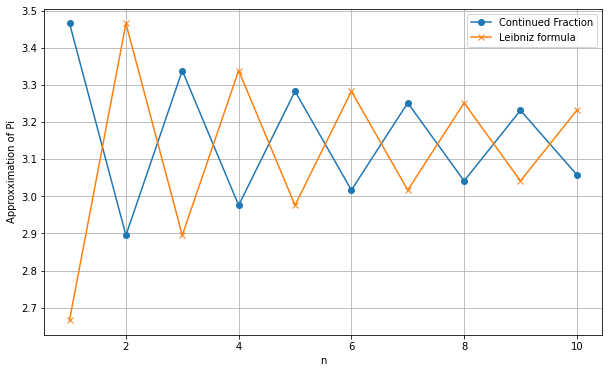

In [111]:
import matplotlib.pyplot as plt

row = np.array([i for i in range(1,11)])
cont = np.array([continued_frac(i) for i in range(1,11)])
leb =  np.array([leibniz(i) for i in range(1,11)])
plt.figure(figsize=(10, 6))
plt.plot(row, cont, label="Continued Fraction", marker='o')
plt.plot(row, leb, label="Leibniz formula", marker='x')
plt.xlabel("n")
plt.ylabel("Approxximation of Pi")
plt.legend()
plt.grid(True)
plt.show
